<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/xRFM_TONIoT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# xRFM on TON-IoT Network Dataset
**Algorithm:** xRFM — Recursive Feature Machines with Adaptive Tree Structure  
**Paper:** arXiv:2508.10053 (August 2025)  
**Dataset:** TON-IoT Network Traffic (Multi-class Intrusion Detection)  

> **Novel contribution:** xRFM has never been evaluated on IoT intrusion detection datasets.  
> This notebook applies it to TON-IoT for the first time.

In [1]:
# CONFIG

DRIVE_DATASET = "/content/drive/MyDrive/datasets/toniot_arnob_dataset"
DRIVE_OUT_DIR = "/content/drive/MyDrive/toniot_outputs"

LABEL_COL   = "type"
RANDOM_SEED = 42
TEST_SIZE   = 0.2
VAL_SIZE    = 0.1

# xRFM settings
DEVICE = "cuda"   # use 'cpu' if no GPU available

print("Config loaded.")

Config loaded.


In [3]:
# Install Libraries

!pip install -q xrfm[cu12]
!pip install -q scikit-learn pandas numpy matplotlib seaborn

print("All packages installed restart runtime")

All packages installed restart runtime


In [4]:
# IMPORTS + DRIVE MOUNT + GPU CHECK

import os, glob, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

# GPU check
if not torch.cuda.is_available():
    print("WARNING: No GPU detected. xRFM will run on CPU (slower).")
    print("- Go to Runtime - Change runtime type - T4 GPU - Save")
    DEVICE = "cpu"
else:
    print(f"GPU confirmed : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"Device        : {DEVICE}")

Mounted at /content/drive
GPU confirmed : Tesla T4
VRAM          : 15.6 GB
Device        : cuda


In [5]:
# LOAD DATA

csv_files = glob.glob(os.path.join(DRIVE_DATASET, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    try:
        dfs.append(pd.read_csv(f, low_memory=False))
    except Exception as e:
        print(f"  Skipped {f}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total rows   : {len(df):,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nLabel distribution:\n{df[LABEL_COL].value_counts()}")

Found 1 CSV files
Total rows   : 211,043
Total columns: 44

Label distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


In [6]:
# PREPROCESS

# Drop label + non-feature columns
drop_cols = [LABEL_COL]
for col in ["ts", "src_ip", "dst_ip", "src_mac", "dst_mac"]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y_raw = df[LABEL_COL]

# Encode string labels to integers
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

# Keep numeric features only + replace inf
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Features     : {X.shape[1]}")

# Split FIRST — 70 / 10 / 20 — before any imputation or scaling
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED,
    stratify=y_tv
)
print(f"\nTrain : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

# Impute NaN using TRAIN median only (no data leakage)
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)

# Scale using TRAIN statistics only (no data leakage)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

n_features = X_train_s.shape[1]
print(f"\nFeatures after preprocessing : {n_features}")
print("Preprocessing complete — no data leakage")

Classes (10): ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Features     : 17

Train : 147,729
Val   : 21,105
Test  : 42,209

Features after preprocessing : 17
Preprocessing complete — no data leakage


In [7]:
# EVALUATION HELPER

def evaluate(model_name, y_true, y_pred, label_names, out_dir):
    acc         = accuracy_score(y_true, y_pred)
    f1_macro    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} — Results")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weighted:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_names, zero_division=0)}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    path = os.path.join(out_dir, f"{model_name.lower().replace(' ', '_')}_cm.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")

    return {
        "model": model_name,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

print("Evaluation helper ready.")

Evaluation helper ready.


In [8]:
# xRFM TRAINING


from xrfm import xRFM

xrfm_model = xRFM(
    tuning_metric='accuracy',    # optimise for accuracy during internal HPO
    device=DEVICE,               # 'cuda' or 'cpu'
    min_subset_size=10000,       # minimum samples per tree leaf
    split_method='top_vector_agop_on_subset'  # AGOP-based splitting
)

print("Training xRFM on TON-IoT...")
print("(xRFM performs its own internal hyperparameter search — no manual tuning needed)")

t0 = time.time()

xrfm_model.fit(
    X_train_s, y_train,
    X_val_s,   y_val
)

train_time = time.time() - t0
print(f"\nxRFM training complete in {train_time:.1f}s ({train_time/60:.1f} min)")

None
Training xRFM on TON-IoT...
(xRFM performs its own internal hyperparameter search — no manual tuning needed)
Fitting xRFM with 1 trees and 0 iterations per tree


Building trees:   0%|          | 0/1 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
Using cheap batch size
Optimal M batch size: 3309
Time taken for round 4: 0.0359189510345459 seconds
Using cheap batch size
Optimal M batch size: 3309
Using top_vector_agop_on_subset split method
Getting AGOP on subset
X_train torch.Size([10912, 17]) y_train torch.Size([10912, 10]) X_val torch.Size([575, 17]) y_val torch.Size([575, 10])
Fitting RFM with ntrain: 10912, d: 17, and nval: 575
Using cheap batch size
Optimal M batch size: 3574
Time taken for round 0: 0.4952993392944336 seconds
Using cheap batch size
Optimal M batch size: 3574
Time taken for round 1: 0.5136439800262451 seconds
Using cheap batch size
Optimal M batch size: 3574
Time taken for round 2: 0.5062003135681152 seconds
Using cheap batch size
Optimal M batch size: 3574
Time taken for round 3: 0.5058431625366211 seconds
Using cheap batch size
Optimal M batch size: 3574
Time taken for round 4: 0.506864070892334 seconds
Using cheap batch size
Optimal M batch size: 3574
Usi

Building trees: 100%|██████████| 1/1 [15:50<00:00, 950.72s/it]


Using cheap batch size
Optimal M batch size: 3308
Time taken for round 0: 0.03109455108642578 seconds
Using cheap batch size
Optimal M batch size: 3308
Time taken for round 1: 0.035910606384277344 seconds
Using cheap batch size
Optimal M batch size: 3308
Time taken for round 2: 0.036992549896240234 seconds
Using cheap batch size
Optimal M batch size: 3308
Time taken for round 3: 0.03499913215637207 seconds
Using cheap batch size
Optimal M batch size: 3308
Time taken for round 4: 0.03559422492980957 seconds
Using cheap batch size
Optimal M batch size: 3308


Tuning split temperature: 100%|██████████| 36/36 [00:10<00:00,  3.51it/s]

Selected split_temperature=0.03953071244130627 based on validation accuracy=0.981568

xRFM training complete in 961.2s (16.0 min)


Using soft routing for tree prediction
Inference time : 0.33s for 42,209 samples
                (0.0079 ms per sample)

  xRFM — Results
  Accuracy      : 0.9801
  F1 (macro)    : 0.9419
  F1 (weighted) : 0.9800

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      4000
        ddos       0.97      0.96      0.97      4000
         dos       0.98      0.97      0.98      4000
   injection       0.96      0.95      0.95      4000
        mitm       0.64      0.58      0.61       209
      normal       1.00      1.00      1.00     10000
    password       0.99      0.98      0.99      4000
  ransomware       0.99      1.00      1.00      4000
    scanning       0.98      0.98      0.98      4000
         xss       0.93      0.97      0.95      4000

    accuracy                           0.98     42209
   macro avg       0.94      0.94      0.94     42209
weighted avg       0.98      0.98      0.98     42209



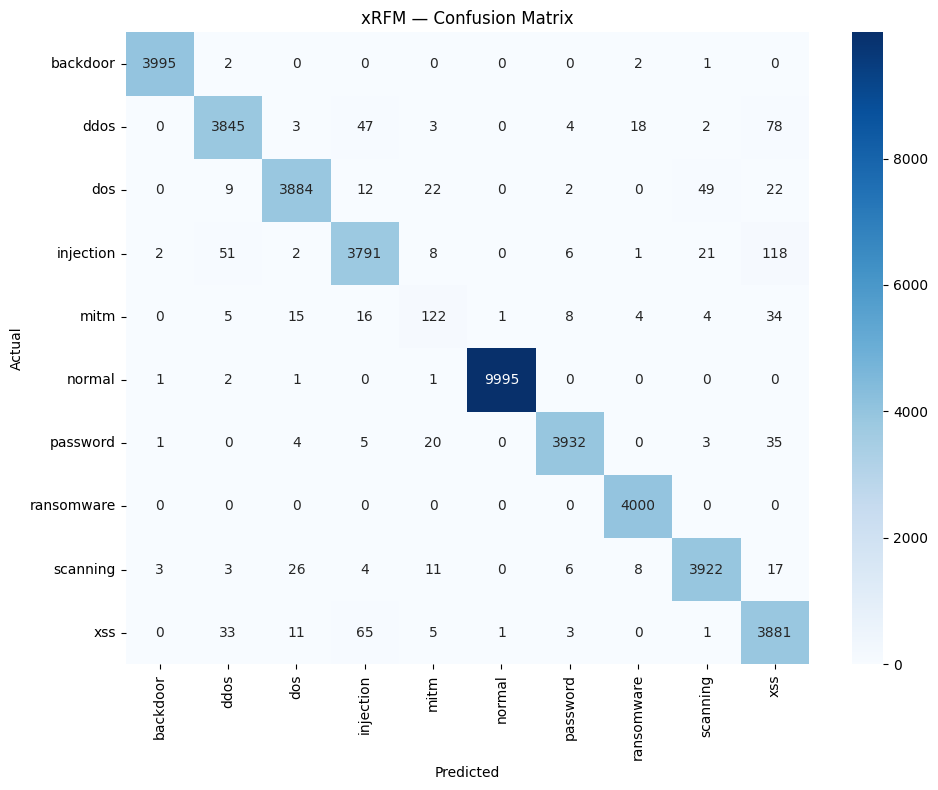

Saved: /content/drive/MyDrive/toniot_outputs/xrfm_cm.png


In [9]:
# xRFM TEST EVALUATION

t0 = time.time()
xrfm_preds = xrfm_model.predict(X_test_s)
infer_time = time.time() - t0

print(f"Inference time : {infer_time:.2f}s for {len(X_test_s):,} samples")
print(f"                ({infer_time / len(X_test_s) * 1000:.4f} ms per sample)")

xrfm_results = evaluate(
    "xRFM", y_test, xrfm_preds,
    label_names=list(le.classes_),
    out_dir=DRIVE_OUT_DIR
)

AGOP extraction note: 'xRFM' object has no attribute 'tree_'
Falling back to sklearn-style permutation importance...
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tree prediction
Using soft routing for tr

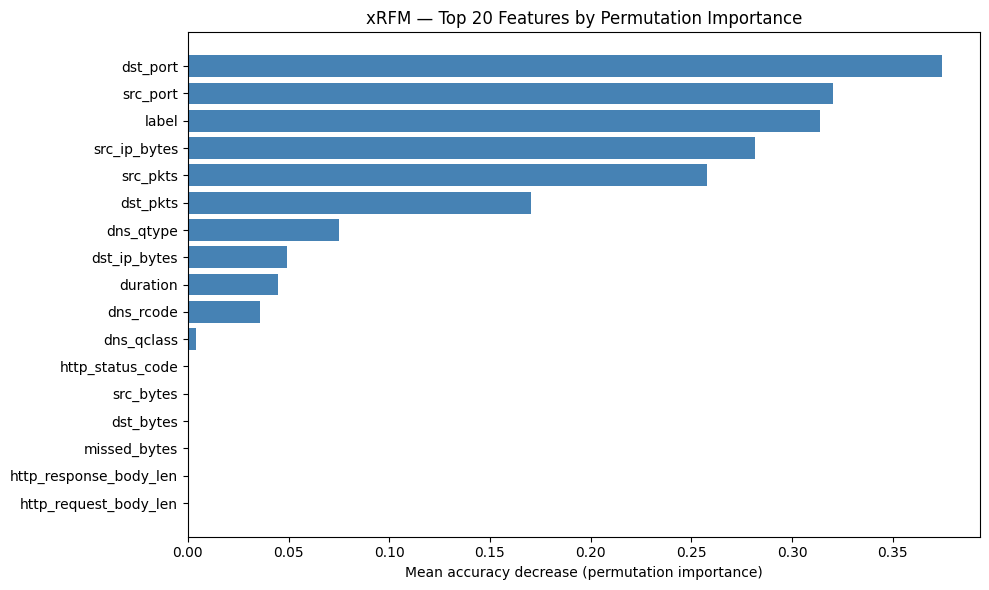

Permutation importance plot saved: /content/drive/MyDrive/toniot_outputs/xrfm_perm_importance.png


In [10]:
# AGOP FEATURE IMPORTANCE

feature_names = list(X_train.columns)

try:
    root_rfm = xrfm_model.tree_.leaf_models[0]  # adjust if API differs
    agop_diag = root_rfm.M.diagonal().cpu().numpy()

    # Normalise
    agop_diag = agop_diag / agop_diag.sum()

    top_n = 20
    top_idx = np.argsort(agop_diag)[::-1][:top_n]
    top_features = [feature_names[i] for i in top_idx]
    top_scores   = agop_diag[top_idx]

    plt.figure(figsize=(10, 6))
    plt.barh(top_features[::-1], top_scores[::-1], color="steelblue")
    plt.xlabel("Normalised AGOP diagonal (feature importance)")
    plt.title("xRFM — Top 20 Features by AGOP Importance")
    plt.tight_layout()
    fig_path = os.path.join(DRIVE_OUT_DIR, "xrfm_agop_importance.png")
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print(f"AGOP feature importance plot saved: {fig_path}")

except Exception as e:
    print(f"AGOP extraction note: {e}")
    print("Falling back to sklearn-style permutation importance...")

    from sklearn.inspection import permutation_importance
    perm = permutation_importance(
        xrfm_model, X_test_s, y_test,
        n_repeats=5, random_state=RANDOM_SEED,
        scoring='accuracy'
    )
    top_n = 20
    top_idx = np.argsort(perm.importances_mean)[::-1][:top_n]
    top_features = [feature_names[i] for i in top_idx]
    top_scores   = perm.importances_mean[top_idx]

    plt.figure(figsize=(10, 6))
    plt.barh(top_features[::-1], top_scores[::-1], color="steelblue")
    plt.xlabel("Mean accuracy decrease (permutation importance)")
    plt.title("xRFM — Top 20 Features by Permutation Importance")
    plt.tight_layout()
    fig_path = os.path.join(DRIVE_OUT_DIR, "xrfm_perm_importance.png")
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print(f"Permutation importance plot saved: {fig_path}")

In [11]:
# OVERFITTING / UNDERFITTING DIAGNOSIS

xrfm_train_preds = xrfm_model.predict(X_train_s)
xrfm_train_acc   = accuracy_score(y_train, xrfm_train_preds)
xrfm_train_f1    = f1_score(y_train, xrfm_train_preds, average="macro", zero_division=0)

print("-" * 50)
print("xRFM — Train vs Test Diagnosis")
print("-" * 50)
print(f"  Train Acc    : {xrfm_train_acc:.4f}")
print(f"  Test  Acc    : {xrfm_results['accuracy']:.4f}")
print(f"  Train F1     : {xrfm_train_f1:.4f}")
print(f"  Test  F1     : {xrfm_results['f1_macro']:.4f}")
print()

acc_gap = xrfm_train_acc - xrfm_results['accuracy']
if acc_gap > 0.05:
    print(f" Generalisation gap: {acc_gap:.4f} — possible overfitting")
elif xrfm_results['accuracy'] < 0.80:
    print("Low test accuracy — possible underfitting")
else:
    print(f" Generalisation gap: {acc_gap:.4f} — model generalises well")

print(f"\n  Training time : {train_time:.1f}s")
print(f"  Inference time: {infer_time:.2f}s ({len(X_test_s):,} samples)")

Using soft routing for tree prediction
--------------------------------------------------
xRFM — Train vs Test Diagnosis
--------------------------------------------------
  Train Acc    : 0.9872
  Test  Acc    : 0.9801
  Train F1     : 0.9636
  Test  F1     : 0.9419

 Generalisation gap: 0.0072 — model generalises well

  Training time : 961.2s
  Inference time: 0.33s (42,209 samples)


In [12]:
# SAVE RESULTS

results_df = pd.DataFrame([{
    "model"        : "xRFM",
    "paper"        : "arXiv:2508.10053 (2025)",
    "dataset"      : "TON-IoT Network",
    "train_samples": len(X_train),
    "test_samples" : len(X_test),
    "n_features"   : n_features,
    "n_classes"    : num_classes,
    "accuracy"     : xrfm_results["accuracy"],
    "f1_macro"     : xrfm_results["f1_macro"],
    "f1_weighted"  : xrfm_results["f1_weighted"],
    "train_acc"    : xrfm_train_acc,
    "train_f1"     : xrfm_train_f1,
    "train_time_s" : round(train_time, 2),
    "infer_time_s" : round(infer_time, 4),
}])

csv_path = os.path.join(DRIVE_OUT_DIR, "xrfm_toniot_results.csv")
results_df.to_csv(csv_path, index=False)

print("\n-- FINAL RESULTS --")
print(results_df.T.to_string())
print(f"\nResults saved to: {csv_path}")


-- FINAL RESULTS --
                                     0
model                             xRFM
paper          arXiv:2508.10053 (2025)
dataset                TON-IoT Network
train_samples                   147729
test_samples                     42209
n_features                          17
n_classes                           10
accuracy                      0.980052
f1_macro                       0.94186
f1_weighted                   0.980017
train_acc                     0.987247
train_f1                      0.963577
train_time_s                    961.16
infer_time_s                    0.3339

Results saved to: /content/drive/MyDrive/toniot_outputs/xrfm_toniot_results.csv
